In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

This notebook, intended not as a referance meteral, but as my own notes, takes the following steps toward pricing a swaption from first principles:
1. Extract forward rates from UST yeild curve (UST is eaysier to acsess than SOFR).
2. Compute discount factors allong forward curve.
3. Demonstrate valuation of forward cash flows.
4. Implement naive MC forward rates path genorator.
5. Run MC simulation on swap or swaption cash flows. (work in progress)

### 1. Extract forward rates from UST yeild curve.
First, we must be able to extract the forward rates curve from real data. Since I have best acsess to tresury bonds at the 1,2,3,4,6 month and 1,2,3,5 year marks, I will need to take that specific form as input. I will convert this data into an array representing the current forward rate each quarter for five years.

To solve for forward rates in an arb free market, we can enforce equality between investing for some peorid $t_2$ at a known spot rate of $r_2$ and investing for some shorter time $t_1$ at spot rate $r_1$, then reinvesting from $t_1$ to $t_2$ at the unknown forward rate $f$:

$$S_2=S_0e^{r_2t_2}\overset{!}{=}S_{1,f}=S_1e^{f(t_2-t_1)}=S_0e^{r_1t_1}e^{f(t_2-t_1)}$$
$$\rightarrow r_2t_2\overset{!}{=}r_1t_1+f(t_2-t_1)$$
$$\rightarrow f=\frac{r_2t_2-r_1t_1}{t_2-t_1}$$

This equations allows us to solve for the forward rate between any two, known points (r,t). However, we still must interpolate results in reagons where we do not know one or both of the end points. The simplest scheme is to assume the rate is constant during that peorid, i.e. $f_{t \rightarrow T_2}=f_{T_1 \rightarrow T_2}$ for any known forward rate $f_{T_1 \rightarrow T_2}$ over time $T_1<t<T_2$.

Tresury data is from: https://www.cnbc.com/markets/bonds/ as of Jul 17, 2026 (except first data point is SOFR for index allignment). Rates must be converted from BEY to EAY using $EAY=(1+\frac{BEY}{2})^2-1$, then to continuously compounding form using $e^{r_{CC}}=1+EAY \rightarrow r_{CC}=\ln({1+EAY})$.

In [2]:
UST_spot_BEY = np.array([3.590, 3.803, 3.927, 4.004, 4.183, 4.218, 4.28])/100
UST_days     = np.array([0, 90,    180,   360,   360*2, 360*3, 360*5])
UST_spot_EAY = (1+UST_spot_BEY/2)**2-1
UST_spot_CC  = np.log(1+UST_spot_EAY)
print(UST_spot_CC)

[0.0355816  0.03767295 0.03888944 0.03964447 0.04139857 0.04174137
 0.04234847]


[]

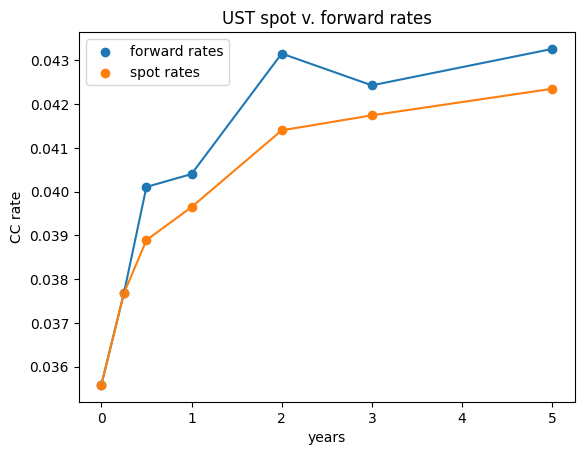

In [3]:
f = lambda r1,t1, r2,t2: (r2*t2-r1*t1)/(t2-t1)

#from this point on, we can assume all rates are CC annual
UST_forward = np.zeros_like(UST_spot_CC)

for i in range(len(UST_spot_CC)):
    if i == 0: #since we get the first forward for free
        UST_forward[i] = UST_spot_CC[i]
    else:
        UST_forward[i] = f(UST_spot_CC[i-1], UST_days[i-1], UST_spot_CC[i], UST_days[i])

plt.scatter(UST_days/360, UST_forward, label='forward rates')
plt.plot(UST_days/360, UST_forward)
plt.scatter(UST_days/360, UST_spot_CC, label='spot rates')
plt.plot(UST_days/360, UST_spot_CC)
plt.title('UST spot v. forward rates')
plt.xlabel('years')
plt.ylabel('CC rate')
plt.legend()
plt.plot()

[]

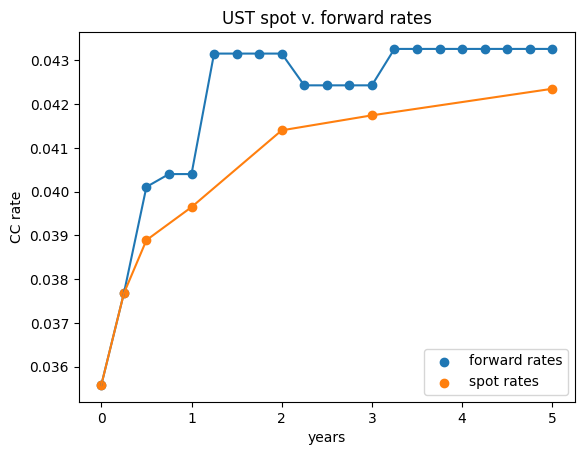

In [4]:
days = np.linspace(0, 5*4*90, 5*4+1)
buckets = np.digitize(days, UST_days, right=True)
UST_forwards = np.array([UST_forward[i] for i in buckets])

plt.scatter(days/360, UST_forwards, label='forward rates')
plt.plot(days/360, UST_forwards)
plt.scatter(UST_days/360, UST_spot_CC, label='spot rates')
plt.plot(UST_days/360, UST_spot_CC)
plt.title('UST spot v. forward rates')
plt.xlabel('years')
plt.ylabel('CC rate')
plt.legend()
plt.plot()

### 2. Compute discount factors allong forward curve.
We must now construct the discount factors (DF) ascocated with any rates curve. Rates curves will be expressed as an array with each position being the quarterly rate (approxamated as 90 days) for a peorid of 5 years. For continuously compounding rates: $DF(t)=e^{-r(t)*t}$ or for descretly compounding rates: $DF(t)=\frac{1}{(1+r(t))^t}$. For now, we will consider a simplified calendar (exactly 90 days per quarter), and continuously compounding rates.

To properly compute the DF *allong* the forward curve, we must itterate in the following way: $DF_{n}=DF_{n-1}e^{-r_n*t_n}$, where $r_n$ is the rate from $n-1\rightarrow n$ and $t_n$ is the (verrible) time step on the same domain.

In [5]:
#due to the need to referance the prior DF, this must be itterative, not vectorized
def rateToDF(forwards, days):
  dfs = np.zeros_like(forwards)
  for i, r in enumerate(forwards):
    if i == 0:
      dfs[i] = 1.0
    else:
      dfs[i] = dfs[i-1]
      dfs[i] *= np.exp(-r * days[i]/360)
  return dfs

In [6]:
#sanity check: zero rates
zero_curve_5yr = np.zeros(4*5+1)
days = np.ones(4*5+1)*90
days[0] = 0 #represent present day
print('in a zero rate world, the rates curve looks like: ', zero_curve_5yr)
print('giving discount factors of: ', rateToDF(zero_curve_5yr, days))

in a zero rate world, the rates curve looks like:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
giving discount factors of:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Ok, now we are convinced that we can properly solve for the DF, we will apply it to the real rates curve from the above section.

[]

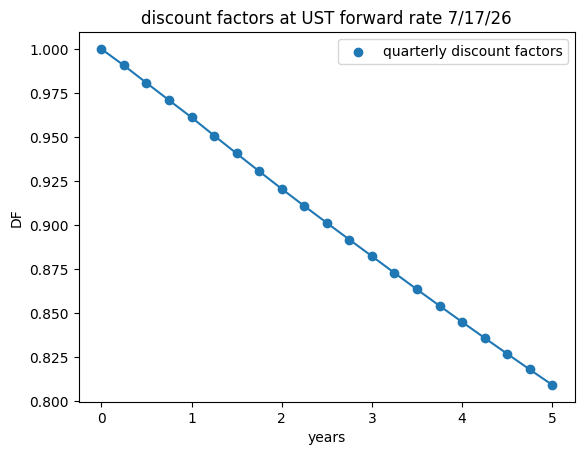

In [7]:
DAYS = np.linspace(0, 4*5*90, 4*5+1)

dfs = rateToDF(UST_forwards, days)
plt.scatter(DAYS/360, dfs, label='quarterly discount factors')
plt.plot(DAYS/360, dfs)
plt.title('discount factors at UST forward rate 7/17/26')
plt.xlabel('years')
plt.ylabel('DF')
plt.legend()
plt.plot()

These points are equivlent to the fair-market-price of a zero coupon bond.

We can cross chek the forward rates against the spot curve by looking at the terminal point, which should be in agreement. (i.e. Investing at spot now for 5 years should match investing at all quarterly forward rates between now and 5 years from now, since the forward curve is, by construction, arb free.)

In [8]:
#PV of moeny 5 years from now at spot
PV_5_spot = np.exp(-UST_spot_CC[-1]*5) #e^r_spot*t
print(PV_5_spot)

0.809173152301617


In [9]:
#PV of moeny 5 years from now, following forward curve
PV_5_FWD = rateToDF(UST_forwards, days)[-1]
print(PV_5_FWD)

0.809173152301617


In [10]:
print(np.isclose(PV_5_spot, PV_5_FWD)) #check that they are the same (within descrete error)

True


Since these match, could we come up with the 5 year DF directly from the spot curve?

Answer: yes, this is done throught a bootstrapping method.

### 3. Demonstrate valuation of forward cash flows.

Having already computed the DFs, valueing forward cash flows is a matter of multiplying by the respective DF (allined in time) and summing. We can try a few kinds of cash flows to make sure the method is sound. First, we can construct something approxamating a bond with quarterly payments and the principal returned after 5 years, then we can construct the fixed leg of a swap with quarterly payments.

In [11]:
#lets construct a bond which pays $1 every quarter, and $101 after 5 years
bond = np.ones_like(UST_forwards)
bond[0] = 0 #following our convention, for index allignment
bond[-1] += 100
print(bond)

[  0.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
   1.   1.   1.   1.   1.   1. 101.]


In [12]:
#now, for PV of this bond, we just multiply UST DFs and sum (equivlent to a vector inner product, so I can use dot)
UST_DFs = rateToDF(UST_forwards, days)
price = bond.dot(UST_DFs)
print('The fair-market-price of the above bond is $', np.round(price, 3), 'based on current UST forward rates.')

The fair-market-price of the above bond is $ 98.874 based on current UST forward rates.


In [13]:
fixed_leg_swap_quartly = lambda notional, r, years: np.array([0] + [notional*r/4 for i in range(years*4)])
fiveper_fiveyr_fixed = fixed_leg_swap_quartly(100, 0.05, 5)
price = fiveper_fiveyr_fixed.dot(UST_DFs)
print('The fixed leg of a swap with the following quartery cash flows: ', fiveper_fiveyr_fixed)
print('has a PV of $', np.round(price,3), 'based on current UST forward rates.')

The fixed leg of a swap with the following quartery cash flows:  [0.   1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25 1.25]
has a PV of $ 22.446 based on current UST forward rates.


#### Detour; par coupon swap rate.

Now that we can both construct forward DFs, and value the fixed leg of a swap, we can determin the par coupon. To do this, we must find the fixed rate at which the floating leg (at UST forwards) and fixed swap leg have the same PV.

For a $1 notional, the future interest payment is the future value minus the principal:

$$interest = S_1-S_0 = e^{rt}-1$$

which has a present value discounted by the forward rate:

$$PV_{interest}=e^{-ft}(e^{rt}-1)=e^{(r-f)t}-e^{-ft}$$

For the floating leg of the swap, valued at today's forward rates, the floating rate is, by construction, the forward rate $f$. However, it is worth noting that this cannot also be true for the fixed leg where $r$ is a single, fixed value for the duration of the swap. So, we can proceed using $f=r$ for the floating leg, but the value of the fixed leg must be computed as it is above with the actual CF discounted at each DF allong the way.

$$r=f: \quad PV_{interest}=e^{(r-r)t}-e^{-rt}=1-e^{-rt}=1-DF$$

So, we can now see that the PV of the floating leg based on today's future rates is path independent because $r$ and $f$ are nessarially the same (they conspire to cancel), but the fixed leg is very much path dependent.

In [14]:
#vlaue of floating leg
1 - UST_DFs[-1]

0.19082684769838298

We can solve for the par coupon rate by making the vlaue each leg of the swap equal, and solving for the fixed coupon:

$$c \sum_{i=1}^n{DF_i} = 1 - DF_n \rightarrow c=\frac{1 - DF_n}{\sum_{i=1}^n{DF_i}}$$

In [15]:
par_coupon = (1-UST_DFs[-1])/np.sum(UST_DFs) * 4
print('par coupon rate: ', np.round(par_coupon,5))

par coupon rate:  0.04026


We can confirm that this par coupon indeed gives us the same PV for both legs of the swap.

In [16]:
floating_PV = 1-UST_DFs[-1]
fixed_PV = np.sum(par_coupon/4 * UST_DFs)

print(np.isclose(floating_PV, fixed_PV))

True


### 4. Implement naive MC forward rates path genorator.

For this step, I considered implementing one factor Hull-White. However, for the purposes of this notebook, it is better to implement the simplest possible model (of my conception) with simular features to referance models, but none of the complexity. This will give all the same intuation while removing any technical beriors.

At the most basic level, to genorate forward rates paths we need a rule by which we get from rate $n$ to $n+1$. This rule must perform a random draw. For starters, we will construct a rule which ensures resulting paths follow a lognormal distrabution since this is widly consitered reasonable. A lognormal random verrible $Y$ can be genorated from a normal random verrible $X$ using $Y=e^{X}$. To give some perameterized control of the charictoristic width (volitility) of $Y$, I will insert $vol$ into the exponential, so $Y=e^{vol*X}$.

$$r_{n+1}=r_nY=r_ne^{vol*X}, \quad X\sim\mathcal{N}(\mu=0,\sigma^2=1)$$

In [17]:
#taking a single step using the above rule with starting rate of 4% and vol=0.1
r0 = 0.04
vol = 0.10

r = r0 * np.exp(vol * np.random.randn())
print(r)

0.03547775105354609


We must apply this rule to a starting rate $r_0$ repeatedly, for the term of the simulation (quartly for five years, in the context of this notebook). This will result in a single simulated rate path. Genorating many such rates paths and looking at there cumulitive properties will complete our MC simulation. I now implement the MC and graphing tools which will enable us to try several rules back-to-back, and select one with desireable properties.

In [18]:
#genorate a single path from: rule (function), init rate, params (dict, requirements free to vary by rule), term (#of quarters)
def generate_fwd_path(f, r0, params, term = 5*4):
  r = r0
  fwd_rates = [r0]
  for i in range(term):
    r = f(r, params, i+1)
    fwd_rates.append(r)
  return fwd_rates

#plot n simulated rates paths next to resulting distrabution of terminal rate values
def plot(f, r0, params, n = 10000):
  t = []

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

  for i in range(n): #genorate n paths
    fwd_rates = generate_fwd_path(f, r0, params)
    t.append(fwd_rates[-1])
    if not i%10: #drawing paths takes longer than genorating them
      ax1.plot(fwd_rates, alpha = 0.20)

  ax1.set_title("Simulated paths")
  ax1.set_xlabel("Time step")
  ax1.set_ylabel("Rate")
  ax2.hist(t, bins=30, orientation='horizontal')
  ax2.set_title("Distribution of terminal rates")
  ax2.set_xlabel("Frequency")
  ax2.set_ylabel("Terminal rate")

  plt.tight_layout()
  plt.show()

For starters, lets look at the paths, and distrabution created by our simple lognormal walk.

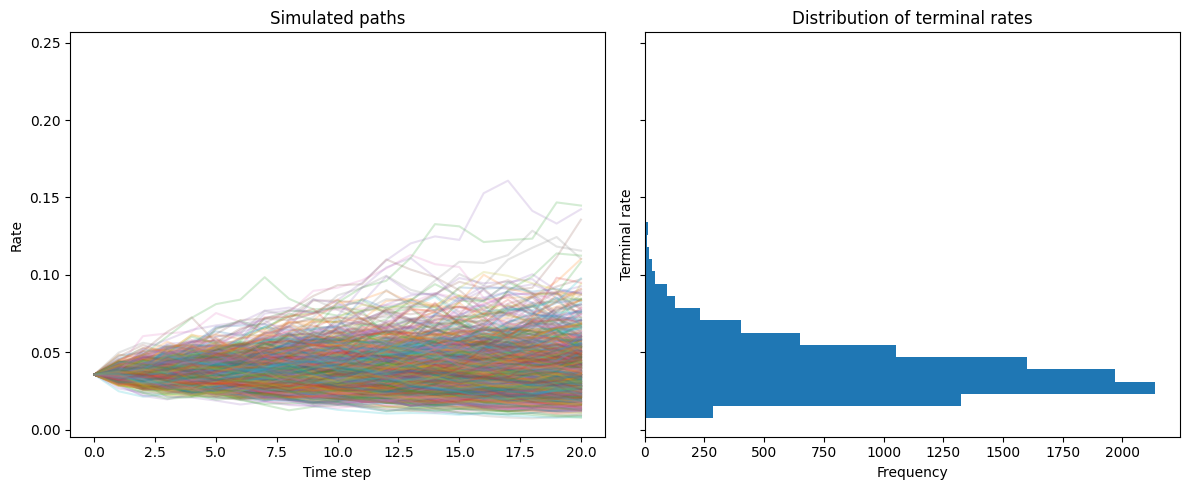

In [19]:
simple = lambda r, params, i: r * np.exp(params['vol'] * np.random.randn())

plot(simple, UST_spot_CC[0], {'vol':0.10})

'Okay,' you say, 'thats great, but we're completely neglecting all of information about the shape of rates futures we so carefully predicted from the spot curve, and in doing so, we ignore all our information from the market. We've reduce the problem to a random walk which follows a distrabution you conjered on vague market intuition.' And so, we arrive at the need for a mean reverting term to be inserted into out model. Of course, a proper mean reverting term would need to satisfy a couple of key properties: undo whatever systematic bias is introduced from the lognormal walk, nudge each step toward its corresponding forward rate, and maintain the overall lognormal terminal rates distribution.

In the above model, over a large number of trials, the mean of the lognormal walk moves by the walk's expected value $\mathbb{E}[Y=e^{vol*X}]=e^{vol^2/2}$. This must be applied as an addative shift to each step, and must be scaled by some characteristic of the width of the distrasbution (say, geometric standard deviation $GSD_Y=e^{vol}$), the direction from this step to the current forward (something like $ \hat{u} = \frac{u}{\lvert u \rvert}, \quad u_i \coloneqq f_i-r_i$), and some tuneable perameter. So, in general, a mathmatically proper mean reverting term would depend on volitility perameters, rely on the outcome of the current step's random draw, and vary in strength according to a user parameter, all while not effecting the global properties of the resulting distrabution. A truely daunting set of requirements. Good this this has not only been done, but in a way which is relativly straightforward to simulate, and gives a closed form analitical solution. So, instead of reinventing Hull-White, I will do something completely naieve and baseless, but which will somehow function well enough for this demonstration.

We will add a mean reverting term which takes the distance from this step (post random draw) to the corresponding forward, then multiplies by a constant ($0\le\alpha\le 1$). We can only characterize the two endpoint behivors: $\alpha=0$ matches the above pure lognormal walk; and $\alpha=1$ follows the forwards curve exactly.

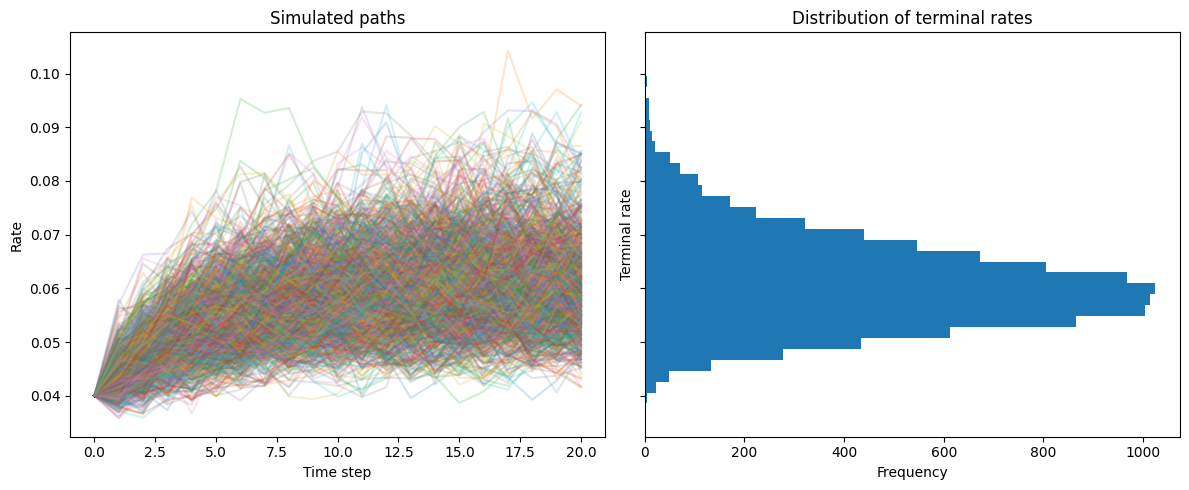

In [20]:
def simple_mr(r, params, i):
    r_next = r * np.exp(params['vol'] * np.random.randn())
    r_next -= params['alpha'] * (r_next - params['fwds'][i])
    return r_next

forward_curve = np.ones(5*4+1) * 0.06 #a flat forwards curve gives a nicer image, later I will use UST_forwards

plot(simple_mr, 0.04, {'vol':0.10, 'fwds':forward_curve, 'alpha':0.2})

### 5. Run MC simulation on swap or swaption cash flows.

We can use the above mean reverting model to genorate paths, from which we extract a distrabution of terminal rates. As before, we can compute a terminal DF from these paths, which represnts the value of the floating leg of a swap $\big( PV_{interest}=1-DF \big)$. So, finding the mean of this distrabution is esentially the same as finding the value of the floating leg of a swap according to our MC method (and its parameters).

In [ ]:
#use same mechinary from above, but this time keep only the distrabution of terminal rates (converted to DFs)
def MCterminalDF(MC_f, r0, params, n):
    DF = []
    for i in range(n): #generate n paths
        fwd_rates = generate_fwd_path(MC_f, r0, params)
        DF.append(rateToDF(fwd_rates, days)[-1]) #same usage as above, see section 2
    return np.array(DF)

In [38]:
DFs = MCterminalDF(simple_mr, UST_forwards[0], {'vol':0.10, 'fwds':UST_forwards, 'alpha':0.20}, 10000)
print(f'PV_interest = {np.round(np.mean(1-DFs),4)}, for mean of MC forward rates DFs')

PV_interest = 0.1875, for mean of MC forward rates DFs


In [39]:
print(f'using UST DFs from section 3, we get: PV_interest = {np.round(1-UST_DFs[-1],4)}')

using UST DFs from section 3, we get: PV_interest = 0.1908


The simularity between our UST and simulated PVs depends on the MC parameters $vol\ \& \ \alpha$. Of these, we can focus on $\alpha$ because it has a much more direct, and understandable effect on mean reversion. We would like to find the minimum mean reversion strength at which the MC DF is in reasonable agreement with the UST DF, and perhaps allong the way, discover the relationship between $\alpha$ and this PV.

In [21]:
#confirm impplemtation is working: simple_mr w/alpha=1 == forwards?
a = generate_fwd_path(simple_mr, UST_forwards[0], {'vol':0.20, 'fwds':UST_forwards, 'alpha':1})
b = UST_forwards
np.isclose(a-b, 0)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [72]:
#repeat MC simulations across 2D (vol, alpha) perameter surface
alphas = np.linspace(0, 1, 40)
mean_DFs = np.zeros((3,alphas.shape[0]))

for vol_i,vol in enumerate([0.1, 0.2, 0.3]):
    for alpha_i,alpha in enumerate(alphas):
        DFs = MCterminalDF(simple_mr, UST_forwards[0], {'vol':0.10, 'fwds':UST_forwards, 'alpha':alpha}, 10000)
        mean_DFs[vol_i, alpha_i] = np.mean(DFs)

print(f'we computed {mean_DFs.shape} mean DFs in (vol, alpha)-space')

we computed (3, 40) mean DFs in (vol, alpha)-space


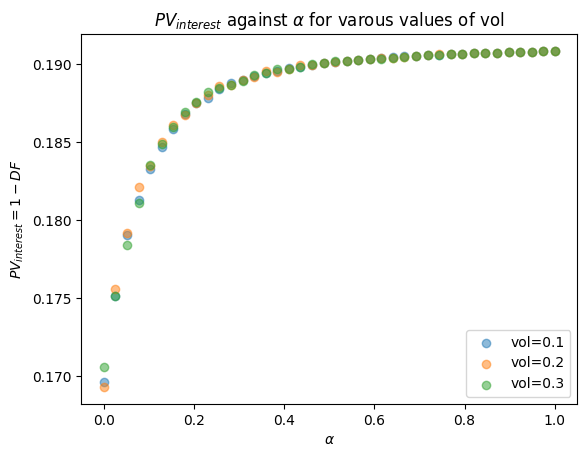

In [84]:
plt.scatter(alphas, 1-mean_DFs[0,:], label='vol=0.1', alpha=0.5)
plt.scatter(alphas, 1-mean_DFs[1,:], label='vol=0.2', alpha=0.5)
plt.scatter(alphas, 1-mean_DFs[2,:], label='vol=0.3', alpha=0.5)
plt.title('$PV_{interest}$ against $\\alpha$ for varous values of vol')
plt.ylabel('$PV_{interest}=1-DF$')
plt.xlabel('$\\alpha$')
plt.legend(loc='lower right')
plt.show()

From this plot we can make two intresting observations.
1. The relationship between $\alpha$ and $PV_{interest}$ is asymtotic and inflects most around $\alpha \in (0.1, 0.3)$.
2. This particular metric is much more sensitive to $\alpha$ then to $vol$.

We can now rerun the simulation, but this time focusing on the inflection reagon, and fixing $\alpha=0.1$.

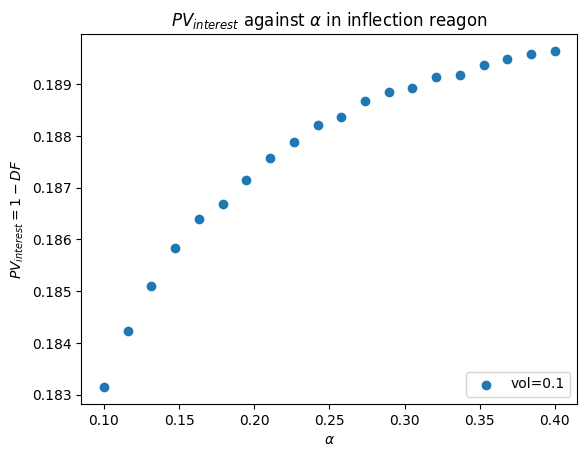

In [94]:
alphas_inflection = np.linspace(0.1, 0.4, 20)
mean_DFs_inflection = np.zeros_like(alphas_inflection)

for i,alpha in enumerate(alphas_inflection):
    DFs_inflection = MCterminalDF(simple_mr, UST_forwards[0], {'vol':0.10, 'fwds':UST_forwards, 'alpha':alpha}, 40000)
    mean_DFs_inflection[i] = np.mean(DFs_inflection)

plt.scatter(alphas_inflection, 1-mean_DFs_inflection, label='vol=0.1')
plt.title('$PV_{interest}$ against $\\alpha$ in inflection reagon')
plt.ylabel('$PV_{interest}=1-DF$')
plt.xlabel('$\\alpha$')
plt.legend(loc='lower right')
plt.show()

For this smaller reagon in $\alpha$, I had to turn the number of paths in each simulation up from 10k to 40k since there is now a lower signal to noise ratio with smaller $\alpha$ step size between points.

From this zoomed-in view, we can see that $\alpha \approx 0.3$ is where $PV_{interest} \approx 0.189$, just 1% difference from $0.191$ from the UST data. 1% is close enough for our purposes, so lets proceed with $(vol, \alpha)=(0.1,0.3)$. 

So, what we've shown is that a nieve MC method which has no firm mathmatical basis and make every possible simplifying assumption can (as long as it exibits some form of mean reversion) be made to agree reasonably with current market condations. 

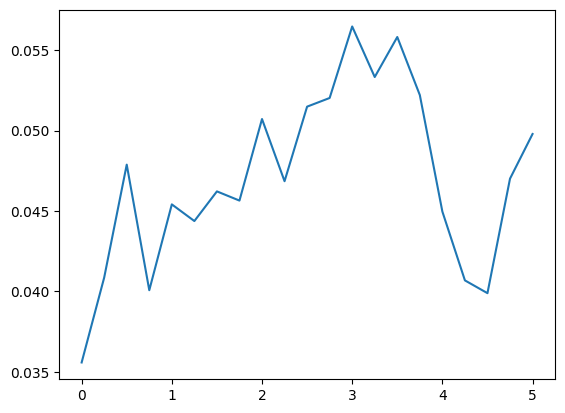

In [ ]:
#create a (random) forward path
fwd_path = generate_fwd_path(simple_mr, UST_spot_CC[0], {'vol':0.10, 'fwds':forward_curve, 'alpha':0.2})
plt.plot(DAYS/360, fwd_path)

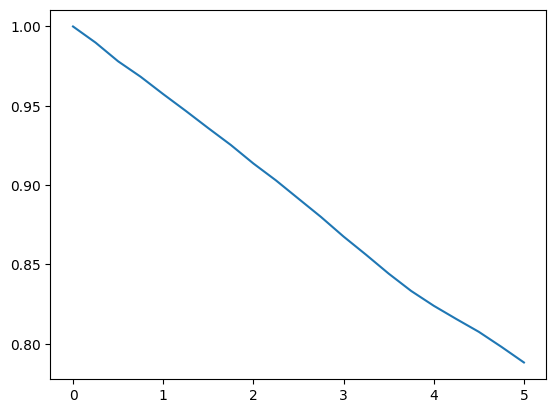

In [ ]:
#calculate discount factors for random forward path
dfs = rateToDF(fwd_path, days)
plt.plot(DAYS/360, dfs)

Since spot, forwards, and DFs all represent the same information, in a simuar manner to the above spot $\rightarrow$ forward adaptor, we can find a DF $\rightarrow$ forward adaptor:

$$DF_{2} = DF_{1} e^{-f(t_2-t_1)}$$


$$ln(\frac{DF_{2}}{DF_{1}})=-f(t_2-t_1)$$


$$f=\frac{ln(\frac{DF_{2}}{DF_{1}})}{t_1-t_2}$$

To extract three year rate two years forward, consider discount factors at $t_1$ and $t_2$:

In [ ]:
#find 3-year rate 2 years forward (the rate from year 2 to year 5):
get_forward_rate = lambda dfs, t1, t2: np.log(dfs[t2*4]/dfs[t1*4])/(t1-t2)
get_forward_rate(dfs, 2, 5)

0.049213059797578444

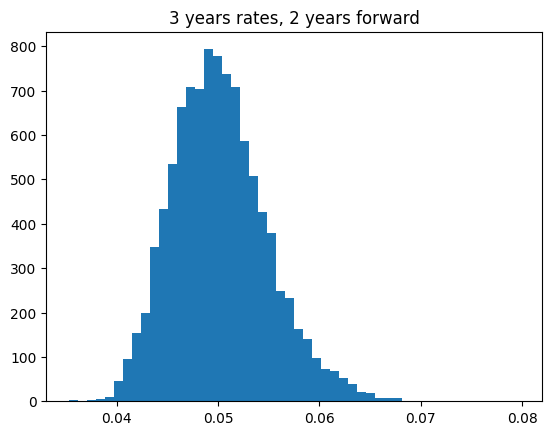

In [ ]:
rates_2_3 = []
for i in range(10000):
  fwd_rates = generate_fwd_path(simple_mr, UST_spot_CC[0], {'vol':0.10, 'fwds':forward_curve, 'alpha':0.2})
  dfs = rateToDF(fwd_rates, days)
  rates_2_3.append(get_forward_rate(dfs, 2, 5))

plt.title('3 years rates, 2 years forward')
plt.hist(rates_2_3, bins=50)
plt.show()